# Faz 2 — Vaka Bazlı Split + YOLO Ön İşleme (Fold 0)

**Amaç:** Faz 1'in `manifest.csv`'sini kullanarak hold-out (~%15) + GroupKFold (k=5) bölünmesi yapmak; sadece **fold 0** için YOLO formatında veri seti üretmek.

**Tasarım:** Aynı vakanın kesitleri ASLA farklı fold'lara düşmez (group=Case Number).

**Filtre garantisi:** YOLO eğitimine yalnızca `Type == "Bounding Box"` annotasyonları girer; `Boundary Slice` annotasyonları YOLO'ya GİTMEZ (Bölüm 3.5'te doğrulanır).

## 1. Ortam

In [1]:
import os, sys
from pathlib import Path
from dotenv import load_dotenv
load_dotenv()

DATA_ROOT = Path(os.environ.get("TR_ABDOMEN_BASE", r"D:/makale-pdf/Proje/abdomen"))
PROJE     = Path(os.environ.get("TR_ABDOMEN_PROJE", r"D:/makale-pdf/Proje"))
CODE      = Path(os.environ.get("TR_ABDOMEN_CODE",  r"D:/makale-pdf/Proje/code"))
EGITIM_DIR = Path(os.environ.get("ABDOMEN_TRAIN_DIR", DATA_ROOT / "Egitim Verisi"))
YARISMA_DIR = Path(os.environ.get("ABDOMEN_TEST_DIR", DATA_ROOT / "Test Verisi"))


os.environ["ABDOMEN_PROJECT_ROOT"] = str(PROJE)
os.environ["ABDOMEN_DATA_ROOT"]    = str(DATA_ROOT)
os.environ["ABDOMEN_TRAIN_DIR"]    = str(EGITIM_DIR)
os.environ["ABDOMEN_TEST_DIR"]     = str(DATA_ROOT / "Yarışma Veri Seti")
os.environ["ABDOMEN_BILGI_XLSX"]   = str(DATA_ROOT / "Bilgi.xlsx")
os.environ["ABDOMEN_OUT_DIR"]      = str(CODE / "outputs")

sys.path.insert(0, str(CODE))
from src.config import SPLIT_DIR, DET_DATA_DIR, SUPER_CLASSES, DEFAULT_SPLIT
print('SPLIT_DIR  :', SPLIT_DIR)
print('DET_DATA_DIR:', DET_DATA_DIR)
print('Fold ayarı : k =', DEFAULT_SPLIT.n_splits, ', hold-out=', DEFAULT_SPLIT.holdout_frac)

SPLIT_DIR  : D:\makale-pdf\Proje\outputs\splits
DET_DATA_DIR: D:\makale-pdf\Proje\outputs\det_data
Fold ayarı : k = 2 , hold-out= 0.15


## 2. GroupKFold Split

In [2]:
from src.splits import make_splits, load_fold, load_holdout
paths = make_splits()
for k, v in paths.items():
    print(f'  {k}: {v}')

  holdout: D:\makale-pdf\Proje\outputs\splits\holdout.csv
  splits: D:\makale-pdf\Proje\outputs\splits\splits.csv
  fold0_train: D:\makale-pdf\Proje\outputs\splits\fold0_train.csv
  fold0_val: D:\makale-pdf\Proje\outputs\splits\fold0_val.csv
  fold1_train: D:\makale-pdf\Proje\outputs\splits\fold1_train.csv
  fold1_val: D:\makale-pdf\Proje\outputs\splits\fold1_val.csv


In [3]:
import pandas as pd
holdout_cases = load_holdout()
fold0_train   = load_fold(fold=0, split='train')
fold0_val     = load_fold(fold=0, split='val')
print(f'Hold-out vaka : {len(holdout_cases)}')
print(f'Fold 0 train  : {len(fold0_train)}')
print(f'Fold 0 val    : {len(fold0_val)}')
overlap   = set(fold0_train) & set(fold0_val)
overlap_h = set(fold0_train + fold0_val) & set(holdout_cases)
print(f'\nTrain∩Val    : {len(overlap)} (0 olmalı)')
print(f'Fold0∪Holdout: {len(overlap_h)} (0 olmalı)')

Hold-out vaka : 98
Fold 0 train  : 277
Fold 0 val    : 277

Train∩Val    : 0 (0 olmalı)
Fold0∪Holdout: 0 (0 olmalı)


In [4]:
manifest = pd.read_csv(SPLIT_DIR / 'manifest.csv')
manifest['super_labels'] = manifest['super_labels'].fillna('').astype(str)

def count_classes(cases):
    sub = manifest[manifest['case'].isin(cases)]
    cnt = {s: 0 for s in range(len(SUPER_CLASSES))}
    for v in sub['super_labels']:
        if not v: continue
        for s in v.split(';'):
            if s.strip(): cnt[int(s)] += 1
    return cnt

rows = []
for name, cases in [('train', fold0_train), ('val', fold0_val), ('holdout', holdout_cases)]:
    cnt = count_classes(cases)
    rows.append([name, len(cases)] + [cnt[i] for i in range(len(SUPER_CLASSES))])
dist = pd.DataFrame(rows, columns=['split', 'n_case'] + SUPER_CLASSES)
dist

,split,n_case,acute_cholecystitis,kidney_ureter_stone,acute_pancreatitis,aortic_aneurysm_dissection,acute_appendicitis,acute_diverticulitis
0,train,277,3286,989,3533,5352,791,150
1,val,277,2645,918,3849,5358,816,110
2,holdout,98,1005,330,1314,1925,498,111


## 3. Fold 0 için YOLO Veri Seti

`detection.export_yolo_dataset(fold=0, bbox_only=True)`:
- **BBox filtresi** (`bbox_only=True`): manifest satırları içinde yalnızca `bboxes` sütunu dolu olanlar (yani `Type == "Bounding Box"` annotasyonu taşıyanlar) işlenir
- Annotasyonlu kesitleri PNG (3-kanal HU pencereleme) olarak yazar
- Her PNG için YOLO `.txt` etiketi üretir (yalnızca **Bounding Box** annotasyonlarından)
- `dataset.yaml` oluşturur

In [5]:
from src.detection import export_yolo_dataset
fold = 0
fold_dir = export_yolo_dataset(fold=fold, include_val_negatives=False, bbox_only=True)
print('YOLO veri seti hazır:', fold_dir)

BBox filtresi: 7,303 bbox'sız satır dışlandı → 31,965 kesit işlenecek


YOLO fold0:   0%|          | 0/26982 [00:00<?, ?it/s]C:\Users\ramazan.polat3\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\pydicom\pixel_data_handlers\numpy_handler.py:250: UserWarning: The length of the pixel data in the dataset (1048576 bytes) indicates it contains excess padding. 524288 bytes will be removed from the end of the data
  warnings.warn(msg)
YOLO fold0: 100%|██████████| 26982/26982 [05:16<00:00, 85.26it/s] 

YOLO veri seti hazır: D:\makale-pdf\Proje\outputs\det_data\fold0


In [6]:
train_imgs = list((fold_dir / 'images' / 'train').glob('*.png'))
val_imgs   = list((fold_dir / 'images' / 'val').glob('*.png'))
train_lbls = list((fold_dir / 'labels' / 'train').glob('*.txt'))
val_lbls   = list((fold_dir / 'labels' / 'val').glob('*.txt'))
print(f'Train: {len(train_imgs):,} PNG, {len(train_lbls):,} label')
print(f'Val  : {len(val_imgs):,} PNG, {len(val_lbls):,} label')
print(f'\nÖrnek etiket ({train_lbls[0].name}):')
print(train_lbls[0].read_text()[:300])
print(f'\ndataset.yaml:')
print((fold_dir / 'dataset.yaml').read_text())

Train: 13,720 PNG, 13,720 label
Val  : 13,260 PNG, 13,260 label

Örnek etiket (20001_100007.txt):
1 0.500977 0.578125 0.021484 0.023438

dataset.yaml:
path: D:\makale-pdf\Proje\outputs\det_data\fold0
train: images/train
val: images/val
names:
  0: acute_cholecystitis
  1: kidney_ureter_stone
  2: acute_pancreatitis
  3: aortic_aneurysm_dissection
  4: acute_appendicitis
  5: acute_diverticulitis



## 3.5. YOLO için "Bounding Box" Filtresi — Doğrulama

YOLO eğitimine yalnızca `Type == "Bounding Box"` annotasyonlarının girdiğini **3 katmanlı savunma** ve 4 adım doğrulama ile kanıtlıyoruz:

**Filtre katmanları:**
1. `src/preprocessing.py` — `build_manifest()`: yalnızca `Type == "Bounding Box"` satırları `bboxes` sütununa yazılır
2. `src/detection.py` — `export_yolo_dataset(bbox_only=True)`: manifest `bboxes != ""` koşuluyla filtre uygulanır (savunma derinliği)
3. `src/detection.py` — `_write_yolo_label()`: `bboxes_raw` boş/NaN/eksik ise koordinat üretilmez

**Doğrulama adımları:**
1. **Filtre sabitleri** (`src/preprocessing.py`): `YOLO_ANNOTATION_TYPE = "Bounding Box"`
2. **Bilgi.xlsx ham sayım** vs **manifest sayım** eşleşmeli
3. **Manifest bboxes** ≥ **YOLO .txt kutu sayısı** olmalı
4. Yalnızca Boundary Slice annotasyonu olan kesitlerin YOLO label'ında koordinat **OLMAMALI**

In [7]:
# 1) Filtre sabitleri, Bilgi.xlsx ham tip dağılımı ve export-level filtre kontrolü
import inspect
from src.preprocessing import YOLO_ANNOTATION_TYPE, SEG_ANNOTATION_TYPE
from src.detection import export_yolo_dataset

print(f"YOLO filtre sabiti : '{YOLO_ANNOTATION_TYPE}'")
print(f"Segm filtre sabiti : '{SEG_ANNOTATION_TYPE}'")

# export_yolo_dataset() bbox_only parametresinin varsayılan değerini kontrol et
sig = inspect.signature(export_yolo_dataset)
bbox_only_default = sig.parameters['bbox_only'].default
print(f"\nexport_yolo_dataset(bbox_only={bbox_only_default!r})  ← export-level filtre")
assert bbox_only_default is True, "bbox_only varsayılanı True olmalı!"
print("✓ Export-level filtre varsayılan olarak AÇIK")

ann_xlsx = pd.read_excel(DATA_ROOT / "Bilgi.xlsx", sheet_name="TRAIININGDATA")
ann_xlsx = ann_xlsx[ann_xlsx['Case Number'].isin(fold0_train + fold0_val)]
print(f"\nFold 0 kapsamındaki Bilgi.xlsx satırı: {len(ann_xlsx):,}")
print("Type dağılımı:")
print(ann_xlsx['Type'].value_counts().to_string())

n_bbox_xlsx = int((ann_xlsx['Type'] == YOLO_ANNOTATION_TYPE).sum())
n_bnd_xlsx  = int((ann_xlsx['Type'] == SEG_ANNOTATION_TYPE).sum())
print(f"\nBeklenen YOLO girdisi (Bounding Box) : {n_bbox_xlsx:,}")
print(f"Segmentasyon girdisi (Boundary Slice) : {n_bnd_xlsx:,}")

YOLO filtre sabiti : 'Bounding Box'
Segm filtre sabiti : 'Boundary Slice'

export_yolo_dataset(bbox_only=True)  ← export-level filtre
✓ Export-level filtre varsayılan olarak AÇIK

Fold 0 kapsamındaki Bilgi.xlsx satırı: 22,982
Type dağılımı:
Bounding Box      20693
Boundary Slice     2289

Beklenen YOLO girdisi (Bounding Box) : 20,693
Segmentasyon girdisi (Boundary Slice) : 2,289


## 4. Görsel Sağlama

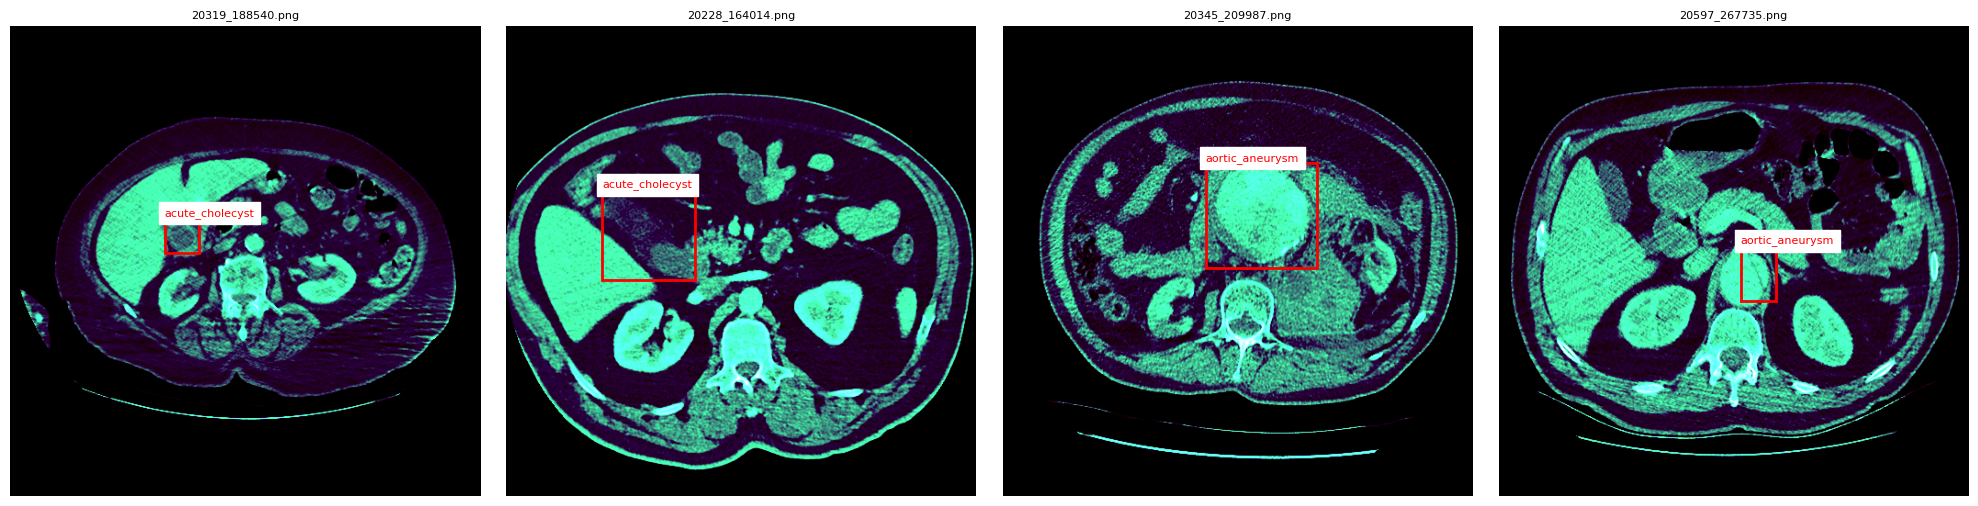

In [9]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import numpy as np

random.seed(7)
samples = random.sample(train_imgs, 4)
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, ip in zip(axes, samples):
    img = np.array(Image.open(ip))
    ax.imshow(img)
    lp = fold_dir / 'labels' / 'train' / (ip.stem + '.txt')
    if lp.exists():
        H, W = img.shape[:2]
        for line in lp.read_text().strip().splitlines():
            p = line.split()
            cls = int(p[0]); cx,cy,w,h = map(float, p[1:5])
            x1 = (cx-w/2)*W; y1 = (cy-h/2)*H
            ax.add_patch(mpatches.Rectangle((x1, y1), w*W, h*H,
                                            linewidth=2, edgecolor='red', facecolor='none'))
            ax.text(x1, y1-3, SUPER_CLASSES[cls][:15], color='red',
                    fontsize=8, backgroundcolor='white')
    ax.set_title(ip.name, fontsize=8); ax.axis('off')
plt.tight_layout(); plt.show()

## 5. Faz 2 Çıktı Özeti

| Çıktı | Yol |
|---|---|
| Splits | `outputs/splits/{holdout,splits,fold0_train,fold0_val}.csv` |
| Manifest (yeni sütunlu) | `outputs/splits/manifest.csv` |
| YOLO data | `outputs/det_data/fold0/{images,labels}/{train,val}/` |
| dataset.yaml | `outputs/det_data/fold0/dataset.yaml` |

**Filtre garantisi (3 katmanlı, kanıtlanmış):**
- `preprocessing.build_manifest()`: yalnızca `Type == "Bounding Box"` satırları `bboxes` sütununa yazılır
- `detection.export_yolo_dataset(bbox_only=True)`: manifest `bboxes != ""` filtresi uygulanır (savunma derinliği)
- `detection._write_yolo_label()`: boş/NaN `bboxes_raw` koordinat üretmez
- Bilgi.xlsx BBox annotasyonu sayısı = manifest `n_bbox_anns` toplamı ✓
- YOLO label kutu sayısı ≤ manifest parse edilmiş BBox sayısı ✓
- Boundary Slice'tan koordinat sızıntısı yok (assertion ile) ✓

**Sonraki:** `Faz3_YOLO_Baseline_1fold.ipynb`